In [7]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

data = []

with open('synthetic_health_lifestyle_dataset.csv', encoding='latin1') as f:
    for line in f:
        try:
            data.append(line.strip().split(','))
        except:
            continue
            
df = df.dropna(how='all') 
print("Cek jumlah Missing value \n " ,df.isnull().sum())


Cek jumlah Missing value 
  0        0
1        0
2     7500
3        0
4        0
5        0
6     7500
7     7500
8     7500
9     7500
10    7500
11       0
12       0
dtype: int64


In [10]:
print("Cek Informasi dataset " ,df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7500 entries, 1 to 7500
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       7500 non-null   float64
 1   1       7500 non-null   float64
 2   2       0 non-null      float64
 3   3       7500 non-null   float64
 4   4       7500 non-null   float64
 5   5       7500 non-null   float64
 6   6       0 non-null      float64
 7   7       0 non-null      float64
 8   8       0 non-null      float64
 9   9       0 non-null      float64
 10  10      0 non-null      float64
 11  11      7500 non-null   float64
 12  12      7500 non-null   float64
dtypes: float64(13)
memory usage: 820.3 KB
Cek Informasi dataset  None


In [13]:
df = df.drop_duplicates()
print ("Hapus data duplikat berhasil")


Hapus data duplikat berhasil


In [14]:
for kolom in df.select_dtypes(include='object').columns:
    df[kolom] = df[kolom].str.strip()
print ("Hapus spasi Berlebih berhasil")

Hapus spasi Berlebih berhasil


In [31]:
print ( "Mengubah Tipe data Berhasil ") 
df = df.apply(pd.to_numeric, errors='coerce')

Mengubah Tipe data Berhasil 


In [17]:
for kolom in df.select_dtypes(include='number').columns:
    df[kolom] = df[kolom].fillna(df[kolom].mean())
print (" Missing Value Berhasil ditangani dengan rata-rata")

 Missing Value Berhasil ditangani dengan rata-rata


In [19]:
print(df.isnull().sum())
print("\n\nCek data setelah dibersihkan\n " ,df.head())

0        0
1        0
2     7500
3        0
4        0
5        0
6     7500
7     7500
8     7500
9     7500
10    7500
11       0
12       0
dtype: int64


Cek data setelah dibersihkan
      0     1   2      3     4     5   6   7   8   9   10   11   12
1  1.0  56.0 NaN  177.6  37.3  11.8 NaN NaN NaN NaN NaN  9.0  8.5
2  2.0  69.0 NaN  169.3  70.7  24.7 NaN NaN NaN NaN NaN  2.0  5.9
3  3.0  46.0 NaN  159.1  69.0  27.3 NaN NaN NaN NaN NaN  3.0  4.8
4  4.0  32.0 NaN  170.6  76.4  26.3 NaN NaN NaN NaN NaN  9.0  6.6
5  5.0  60.0 NaN  158.4  60.4  24.1 NaN NaN NaN NaN NaN  6.0  6.1


In [51]:
print ("Statistik Deskriptif\n")
df = pd.read_csv("synthetic_health_lifestyle_dataset.csv")
print(df.columns)
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
for kolom in df.select_dtypes(include='number').columns:
    df[kolom] = df[kolom].fillna(df[kolom].mean())
    
# Kolom kategorikal → isi dengan modus
for kolom in df.select_dtypes(include='object').columns:
    df[kolom] = df[kolom].fillna(df[kolom].mode()[0])

print("\n\nStatistik Deskriptif BMI\n ")
print(df['BMI'].describe())
print("\n\nMinimum BMI :", df['BMI'].min())
print("Rata-rata BMI :", df['BMI'].mean())
print("Maximum BMI :", df['BMI'].max())
print("Total BMI :", df['BMI'].sum())
print("Jumlah Data BMI :", df['BMI'].count())
print("Median BMI :", df['BMI'].median())
print("Modus BMI :")
print(df['BMI'].mode())
print("Standar Deviasi BMI :", df['BMI'].std())
print("Variansi BMI :", df['BMI'].var())
print("Kuartil 25% BMI :", df['BMI'].quantile(0.25))

print("\n\nStatistik Deskriptif Stress Level\n")
print(df['Stress_Level'].describe())
print("\nMinimum Stress Level :", df['Stress_Level'].min())
print("Rata-rata Stress Level :", df['Stress_Level'].mean())
print("Maximum Stress Level :", df['Stress_Level'].max())
print("Total Stress Level :", df['Stress_Level'].sum())
print("Jumlah Data Stress Level :", df['Stress_Level'].count())
print("Median Stress Level :", df['Stress_Level'].median())

print("Modus Stress Level :")
print(df['Stress_Level'].mode())

print("Standar Deviasi Stress Level :", df['Stress_Level'].std())
print("Variansi Stress Level :", df['Stress_Level'].var())
print("Kuartil 25% Stress Level :", df['Stress_Level'].quantile(0.25))

print("\n\nStatistik Deskriptif Smoker /n")
print(df['Smoker'].describe())
print("\nJumlah Data Smoker :")
print(df['Smoker'].count())
print("\nModus Smoker :")
print(df['Smoker'].mode())
print("\nJumlah kategori Smoker :")
print(df['Smoker'].value_counts())



Statistik Deskriptif

Index(['ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Smoker',
       'Exercise_Freq', 'Diet_Quality', 'Alcohol_Consumption',
       'Chronic_Disease', 'Stress_Level', 'Sleep_Hours'],
      dtype='object')


Statistik Deskriptif BMI
 
count    7500.000000
mean       26.032493
std         6.432411
min         6.500000
25%        21.600000
50%        25.600000
75%        30.100000
max        56.800000
Name: BMI, dtype: float64


Minimum BMI : 6.5
Rata-rata BMI : 26.032493333333335
Maximum BMI : 56.8
Total BMI : 195243.7
Jumlah Data BMI : 7500
Median BMI : 25.6
Modus BMI :
0    25.9
Name: BMI, dtype: float64
Standar Deviasi BMI : 6.432411339358467
Variansi BMI : 41.37591563870738
Kuartil 25% BMI : 21.6


Statistik Deskriptif Stress Level

count    7500.000000
mean        5.591867
std         2.865983
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Stress_Level, dtype: float64

Minimum Stress Lev

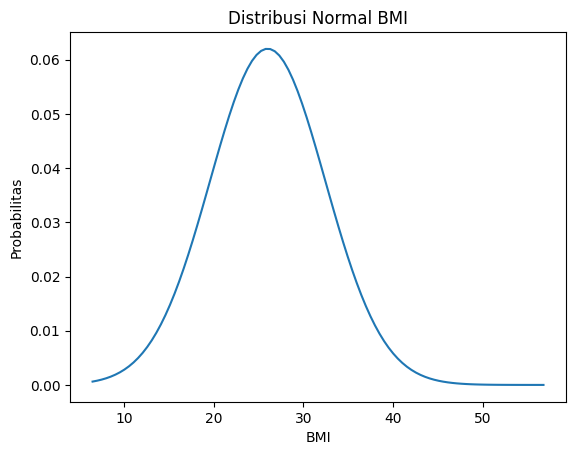

In [38]:
#  DISTRIBUSI NORMAL (BMI)
df = pd.read_csv("synthetic_health_lifestyle_dataset.csv")
df = df.dropna(subset=['Age', 'BMI', 'Stress_Level'])
 
mean_bmi = df['BMI'].mean()
std_bmi = df['BMI'].std()

x = np.linspace(df['BMI'].min(), df['BMI'].max(), 100)
y = norm.pdf(x, mean_bmi, std_bmi)

plt.plot(x, y)
plt.title("Distribusi Normal BMI")
plt.xlabel("BMI")
plt.ylabel("Probabilitas")
plt.show()

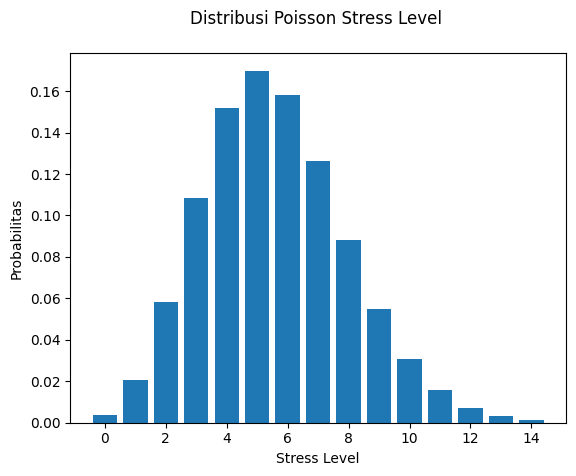

In [29]:
# DISTRIBUSI POISSON (Stress Level)
lambda_ = df['Stress_Level'].mean()

x_poisson = np.arange(0, 15)
y_poisson = poisson.pmf(x_poisson, lambda_)

plt.bar(x_poisson, y_poisson)

plt.title("Distribusi Poisson Stress Level \n")
plt.xlabel("Stress Level")
plt.ylabel("Probabilitas")
plt.show()


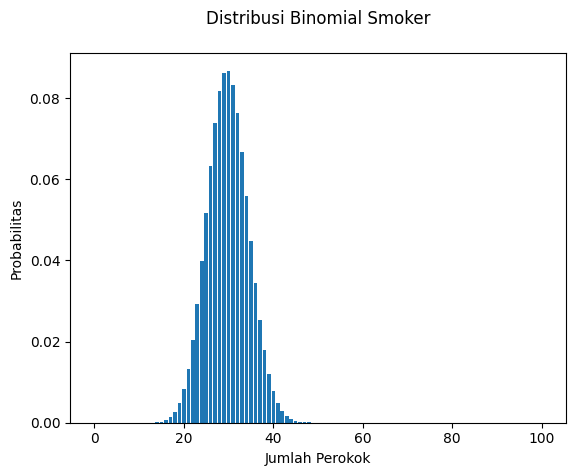

In [28]:
# DISTRIBUSI BINOMIAL (Smoker)

df['Smoker_Binary'] = df['Smoker'].map({
    'Yes': 1,
    'No': 0
})

p = df['Smoker_Binary'].mean()
n = 100
x = np.arange(0, n+1)
y = binom.pmf(x, n, p)

plt.bar(x, y)
plt.title("Distribusi Binomial Smoker\n")
plt.xlabel("Jumlah Perokok")
plt.ylabel("Probabilitas")
plt.show()

In [53]:
print("Pengelompokan Data \n")


print("\nRata-rata BMI berdasarkan Gender")
print(df.groupby('Gender')['BMI'].mean())

print("\nRata-rata Stress Level berdasarkan Gender")
print(df.groupby('Gender')['Stress_Level'].mean())

print("\nRata-rata BMI berdasarkan Smoker")
print(df.groupby('Smoker')['BMI'].mean())

print("\nRata-rata Stress Level berdasarkan Smoker")
print(df.groupby('Smoker')['Stress_Level'].mean())

print("\nRata-rata Sleep Hours berdasarkan Gender")
print(df.groupby('Gender')['Sleep_Hours'].mean())

print("\nRata-rata BMI berdasarkan Chronic Disease")
print(df.groupby('Chronic_Disease')['BMI'].mean())

print("\nJumlah Smoker berdasarkan Gender")
print(df.groupby('Gender')['Smoker'].value_counts())

df['Exercise_Freq_Num'] = df['Exercise_Freq'].map({
    'Daily': 7,
    '3-5 times/week': 4,
    '1-2 times/week': 2
})

print("\nRata-rata Exercise Frequency berdasarkan Gender")
print(df.groupby('Gender')['Exercise_Freq_Num'].mean())

Pengelompokan Data 


Rata-rata BMI berdasarkan Gender
Gender
Female    26.040837
Male      26.099020
Other     25.954326
Name: BMI, dtype: float64

Rata-rata Stress Level berdasarkan Gender
Gender
Female    5.616733
Male      5.650725
Other     5.504715
Name: Stress_Level, dtype: float64

Rata-rata BMI berdasarkan Smoker
Smoker
No     26.014174
Yes    26.075592
Name: BMI, dtype: float64

Rata-rata Stress Level berdasarkan Smoker
Smoker
No     5.590348
Yes    5.595440
Name: Stress_Level, dtype: float64

Rata-rata Sleep Hours berdasarkan Gender
Gender
Female    7.023825
Male      7.008114
Other     6.976015
Name: Sleep_Hours, dtype: float64

Rata-rata BMI berdasarkan Chronic Disease
Chronic_Disease
No     26.013483
Yes    26.111948
Name: BMI, dtype: float64

Jumlah Smoker berdasarkan Gender
Gender  Smoker
Female  No        1765
        Yes        745
Male    No        1783
        Yes        768
Other   No        1715
        Yes        724
Name: count, dtype: int64

Rata-rata Exercise 

              BMI  Stress_Level  Sleep_Hours  Exercise_Freq
Gender                                                     
Female  26.040837      5.616733     7.023825       5.048606
Male    26.099020      5.650725     7.008114       4.999608
Other   25.954326      5.504715     6.976015       5.021730


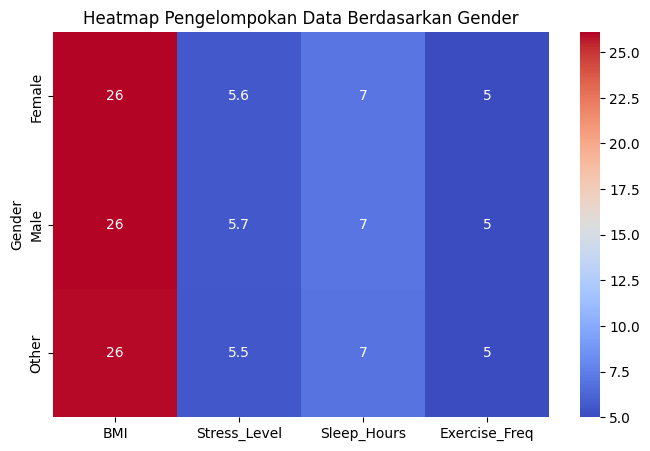

In [82]:
import matplotlib.pyplot as plt
bmi_gender = df.groupby('Gender')['BMI'].mean()
stress_gender = df.groupby('Gender')['Stress_Level'].mean()
sleep_gender = df.groupby('Gender')['Sleep_Hours'].mean()
exercise_gender = df.groupby('Gender')['Exercise_Freq_Num'].mean()

heatmap_data = pd.DataFrame({
    'BMI': bmi_gender,
    'Stress_Level': stress_gender,
    'Sleep_Hours': sleep_gender,
    'Exercise_Freq': exercise_gender
})

print(heatmap_data)
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='coolwarm'
)
plt.title('Heatmap Pengelompokan Data Berdasarkan Gender')
plt.show()

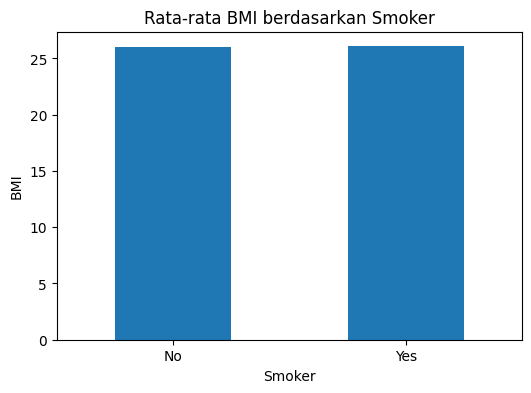

In [83]:
bmi_smoker = df.groupby('Smoker')['BMI'].mean()
plt.figure(figsize=(6,4))
bmi_smoker.plot(kind='bar')

plt.title('Rata-rata BMI berdasarkan Smoker')
plt.xlabel('Smoker')
plt.ylabel('BMI')
plt.xticks(rotation=0)
plt.show()

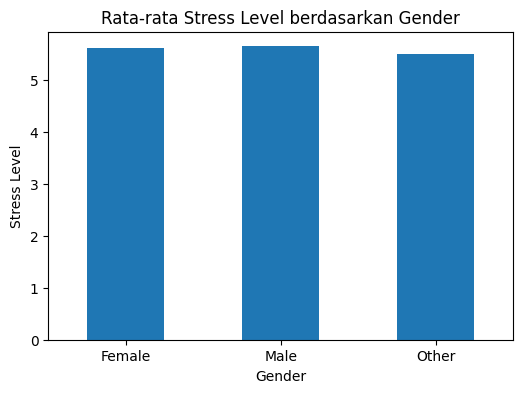

In [84]:
stress_gender = df.groupby('Gender')['Stress_Level'].mean()
plt.figure(figsize=(6,4))
stress_gender.plot(kind='bar')
plt.title('Rata-rata Stress Level berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Stress Level')
plt.xticks(rotation=0)
plt.show()

In [ ]:
Kesimpulan Berdasarkan Hasil Pengelompokan Data :

Berdasarkan hasil pengelompokan data yang telah dilakukan, terlihat bahwa perbedaan antara tiap kategori sebenarnya tidak terlalu jauh, 
sehingga banyak faktor kesehatan pada dataset ini cenderung merata

Pada data BMI berdasarkan gender, rata-rata BMI perempuan sebesar 26.04, laki-laki 26.09, dan other 25.95 Hal ini menunjukkan bahwa gender
tidak terlalu memengaruhi BMI karena selisih nilainya sangat kecil dan semuanya berada di sekitar angka 26

Untuk tingkat stres, rata-rata seluruh gender juga hampir sama, yaitu sekitar 5.5 sampai 5.6 Ini berarti tingkat stres dialami hampir
merata tanpa perbedaan signifikan antara perempuan, laki-laki, maupun other

Kemudian pada kategori smoker, rata-rata BMI antara perokok dan non-perokok juga tidak berbeda jauh , Non-smoker memiliki rata-rata BMI 26.01 
sedangkan smoker 26.07 Tingkat stres antara smoker dan non-smoker juga hampir identik, yaitu sekitar 5.59  Dari sini bisa dilihat bahwa dalam 
dataset ini kebiasaan merokok belum menunjukkan pengaruh yang terlalu besar terhadap BMI maupun stress level

Untuk jam tidur berdasarkan gender, semuanya memiliki rata-rata sekitar 7 jam
Ini menunjukkan bahwa pola tidur responden cukup stabil dan merata di semua gender

Pada kategori chronic disease, orang yang memiliki penyakit kronis memang memiliki rata-rata BMI sedikit lebih tinggi dibanding yang tidak
memiliki penyakit kronis, tetapi perbedaannya tetap kecil sehingga belum terlihat pengaruh yang terlalu besar

Jumlah smoker berdasarkan gender juga cukup seimbang,Jumlah non-smoker jauh lebih banyak dibanding smoker pada semua gender, yang berarti
mayoritas responden memiliki kebiasaan hidup yang lebih sehat dalam aspek merokok

Terakhir, rata-rata frekuensi olahraga berdasarkan gender berada di sekitar angka 5, yang menunjukkan bahwa mayoritas responden cukup rutin
berolahraga beberapa kali dalam seminggu Perbedaannya antar gender juga sangat kecil sehingga kebiasaan olahraga cenderung merata

Secara keseluruhan, dataset ini menunjukkan bahwa faktor gender, kebiasaan merokok, maupun penyakit kronis tidak memberikan perbedaan yang 
terlalu ekstrem terhadap BMI, stress level, maupun jam tidur 
Hampir semua hasil memiliki selisih kecil, sehingga kondisi kesehatan responden pada dataset ini relatif stabil dan seimbang
    

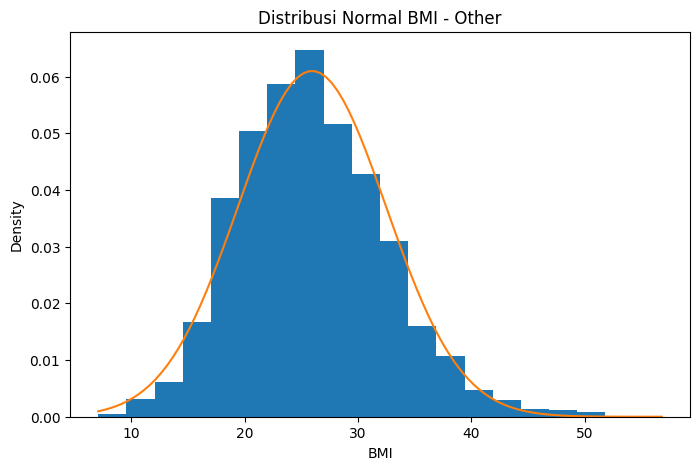

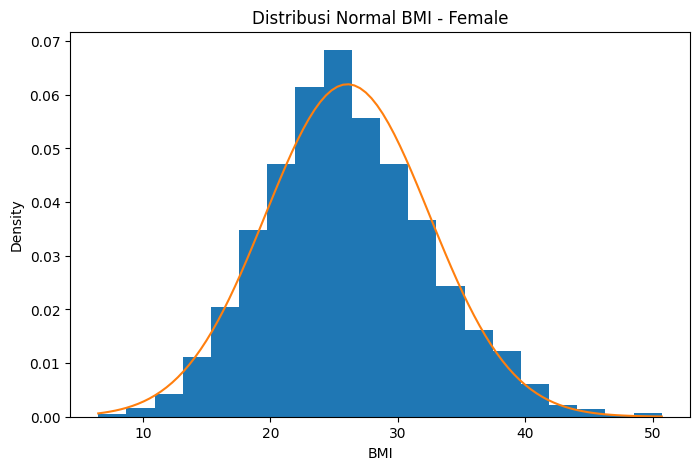

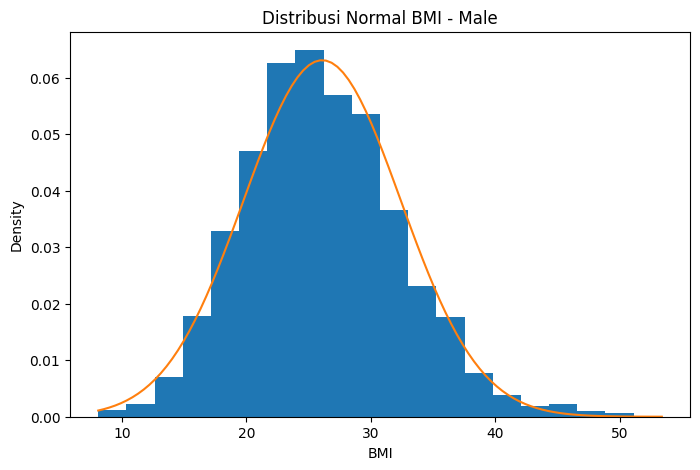

In [54]:
gender_list = df['Gender'].unique()

for gender in gender_list:
    data = df[df['Gender'] == gender]['BMI']
    mean = data.mean()
    std = data.std()
    
    x = np.linspace(data.min(), data.max(), 100)
    y = norm.pdf(x, mean, std)
    
    plt.figure(figsize=(8,5))
    
    plt.hist(data, bins=20, density=True)
    
    plt.plot(x, y)
    
    plt.title(f'Distribusi Normal BMI - {gender}')
    plt.xlabel('BMI')
    plt.ylabel('Density')
    
    plt.show()

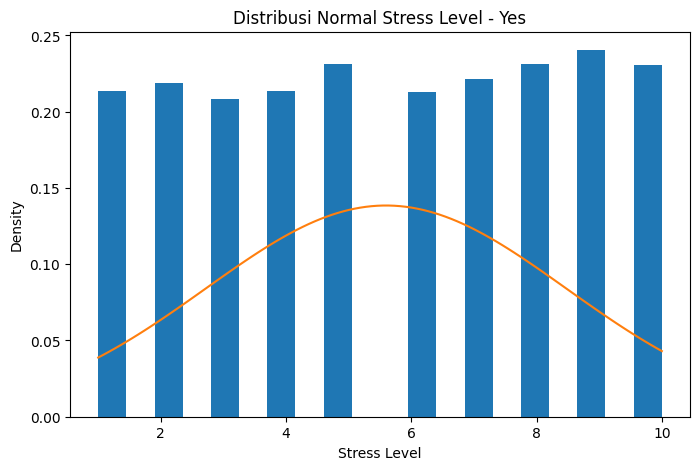

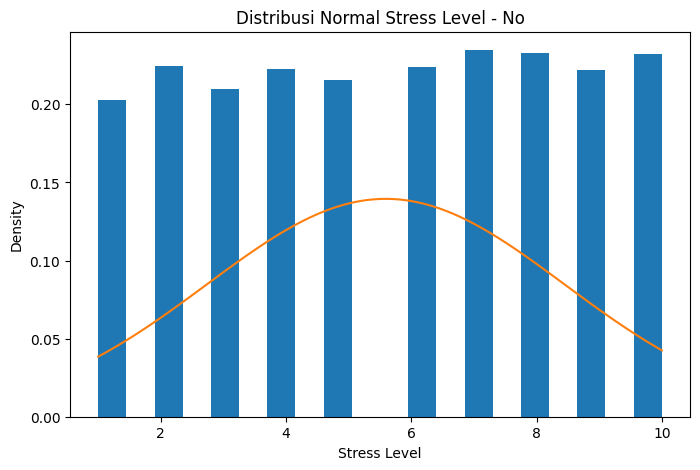

In [55]:
smoker_list = df['Smoker'].unique()

for smoker in smoker_list:
    data = df[df['Smoker'] == smoker]['Stress_Level']
    mean = data.mean()
    std = data.std()
    
    x = np.linspace(data.min(), data.max(), 100)
    y = norm.pdf(x, mean, std)
    plt.figure(figsize=(8,5))
    
    plt.hist(data, bins=20, density=True)
    
    plt.plot(x, y)
    
    plt.title(f'Distribusi Normal Stress Level - {smoker}')
    plt.xlabel('Stress Level')
    plt.ylabel('Density')
    
    plt.show()

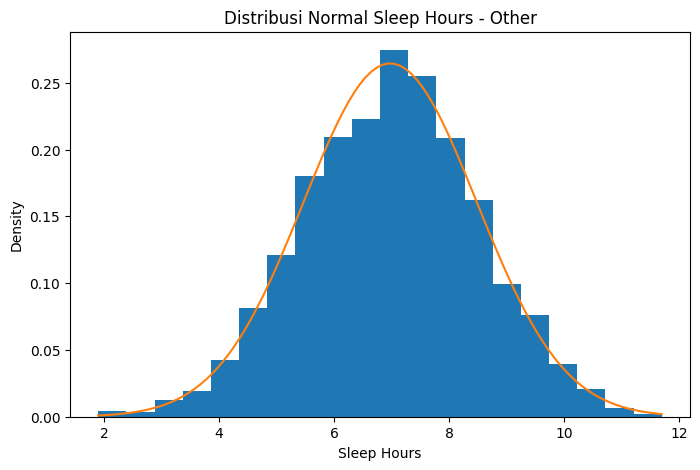

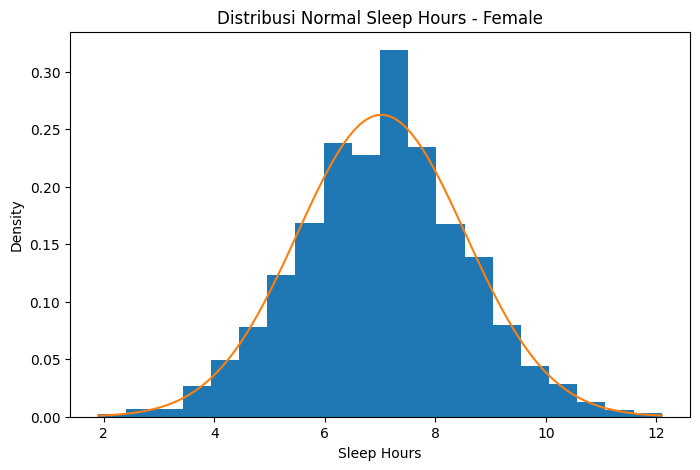

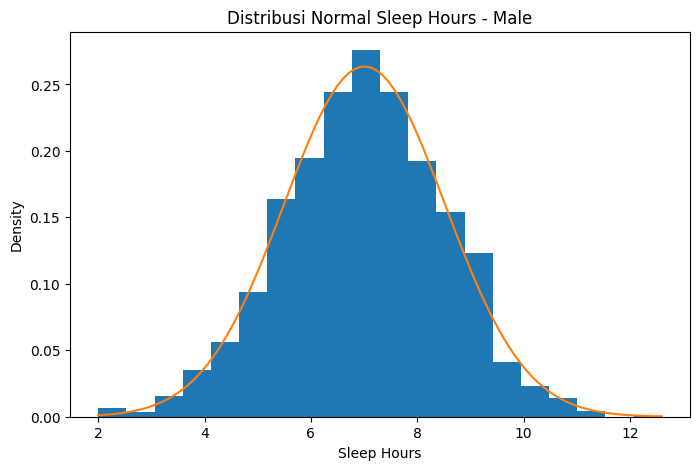

In [56]:
gender_list = df['Gender'].unique()

for gender in gender_list:
    
    data = df[df['Gender'] == gender]['Sleep_Hours']
    
    mean = data.mean()
    std = data.std()
    
    x = np.linspace(data.min(), data.max(), 100)
    y = norm.pdf(x, mean, std)
    
    plt.figure(figsize=(8,5))
    
    plt.hist(data, bins=20, density=True)
    
    plt.plot(x, y)
    
    plt.title(f'Distribusi Normal Sleep Hours - {gender}')
    plt.xlabel('Sleep Hours')
    plt.ylabel('Density')
    
    plt.show()

In [ ]:
Berdasarkan diagram distribusi normal yang telah dibuat, terlihat bahwa sebagian besar data membentuk pola kurva lonceng atau bell curve
Hal ini menunjukkan bahwa data pada dataset cenderung tersebar secara normal dan banyak nilai berada di sekitar rata-rata

Rata-rata simulasi BMI : 26.110324195182656
Standar deviasi simulasi BMI : 6.487466681431653


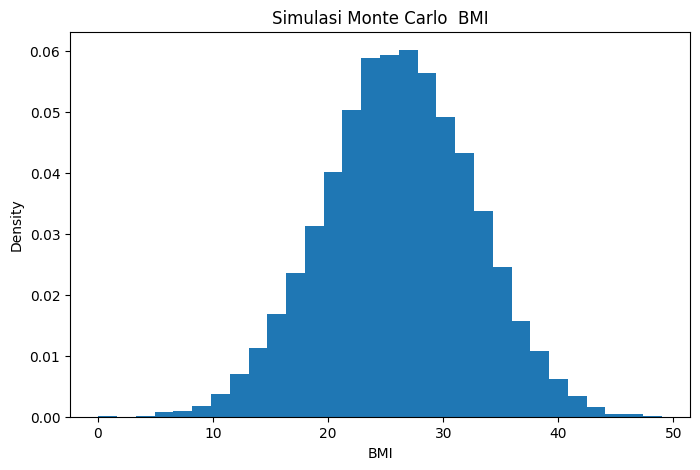

In [59]:
# Ambil mean dan std BMI
mean_bmi = df['BMI'].mean()
std_bmi = df['BMI'].std()

# Simulasi 10.000 data BMI
simulasi_bmi = np.random.normal(mean_bmi, std_bmi, 10000)

print("Rata-rata simulasi BMI :", simulasi_bmi.mean())
print("Standar deviasi simulasi BMI :", simulasi_bmi.std())

plt.figure(figsize=(8,5))
plt.hist(simulasi_bmi, bins=30, density=True)
plt.title("Simulasi Monte Carlo  BMI")
plt.xlabel("BMI")
plt.ylabel("Density")

plt.show()

Rata-rata simulasi Stress Level : 5.576557693968159


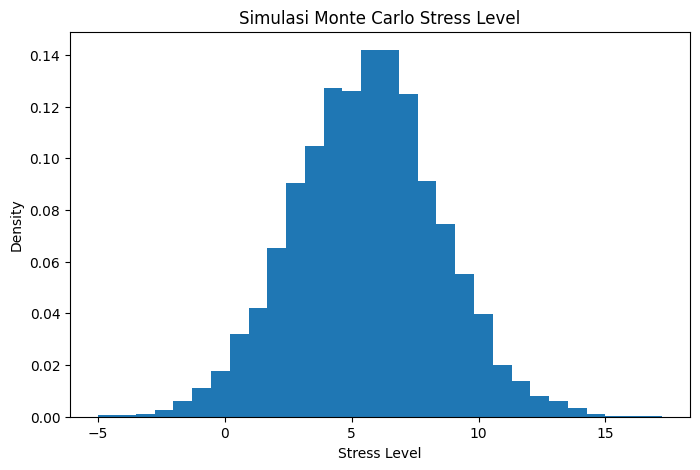

In [60]:
mean_stress = df['Stress_Level'].mean()
std_stress = df['Stress_Level'].std()

simulasi_stress = np.random.normal(mean_stress, std_stress, 10000)

print("Rata-rata simulasi Stress Level :", simulasi_stress.mean())

plt.figure(figsize=(8,5))

plt.hist(simulasi_stress, bins=30, density=True)

plt.title("Simulasi Monte Carlo Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Density")

plt.show()

Rata-rata simulasi Sleep Hours : 6.993451979802945


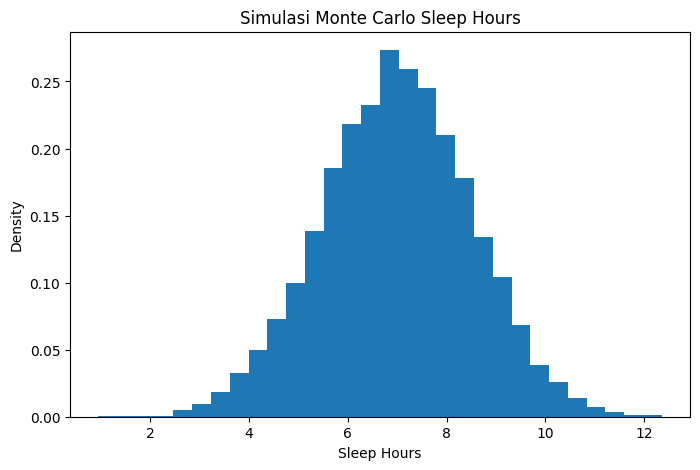

In [62]:
mean_sleep = df['Sleep_Hours'].mean()
std_sleep = df['Sleep_Hours'].std()

simulasi_sleep = np.random.normal(mean_sleep, std_sleep, 10000)

print("Rata-rata simulasi Sleep Hours :", simulasi_sleep.mean())

plt.figure(figsize=(8,5))

plt.hist(simulasi_sleep, bins=30, density=True)

plt.title("Simulasi Monte Carlo Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Density")

plt.show()

In [ ]:
KESIMPULAN BERDASARKAN SIMULASI MONTE CARLO 

Dari simulasi Monte Carlo, distribusi hasil simulasi cenderung mengikuti pola data asli
Sebagian besar hasil simulasi berkumpul di sekitar rata-rata, sehingga mempertegas bahwa data BMI, stress level,
dan sleep hours memiliki distribusi yang cukup normal dan stabil Semakin banyak jumlah simulasi yang dilakukan, 
maka hasil simulasi akan semakin mendekati distribusi asli.

In [63]:
print(" UKURAN TENDENSI SENTRAL \n")
print("\nBMI")
print("Mean :", df['BMI'].mean())
print("Median :", df['BMI'].median())
print("Modus :")
print(df['BMI'].mode())
print("\nStress Level")
print("Mean :", df['Stress_Level'].mean())
print("Median :", df['Stress_Level'].median())
print("Modus :")
print(df['Stress_Level'].mode())
print("\nSleep Hours")
print("Mean :", df['Sleep_Hours'].mean())
print("Median :", df['Sleep_Hours'].median())
print("Modus :")
print(df['Sleep_Hours'].mode())

 UKURAN TENDENSI SENTRAL 


BMI
Mean : 26.032493333333335
Median : 25.6
Modus :
0    25.9
Name: BMI, dtype: float64

Stress Level
Mean : 5.591866666666666
Median : 6.0
Modus :
0    8
Name: Stress_Level, dtype: int64

Sleep Hours
Mean : 7.002933333333333
Median : 7.0
Modus :
0    7.2
Name: Sleep_Hours, dtype: float64


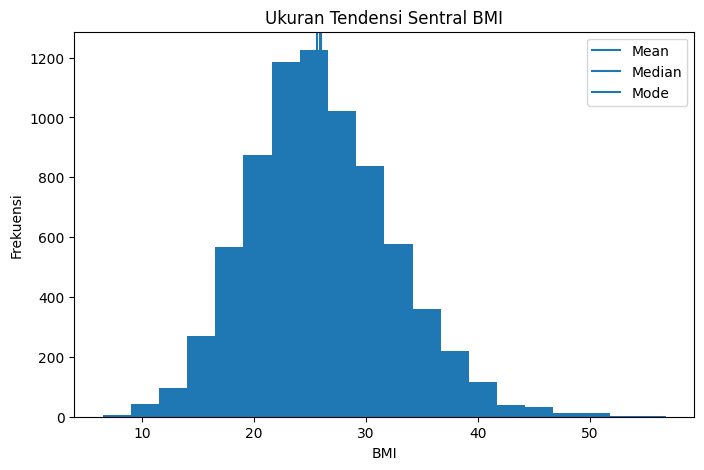

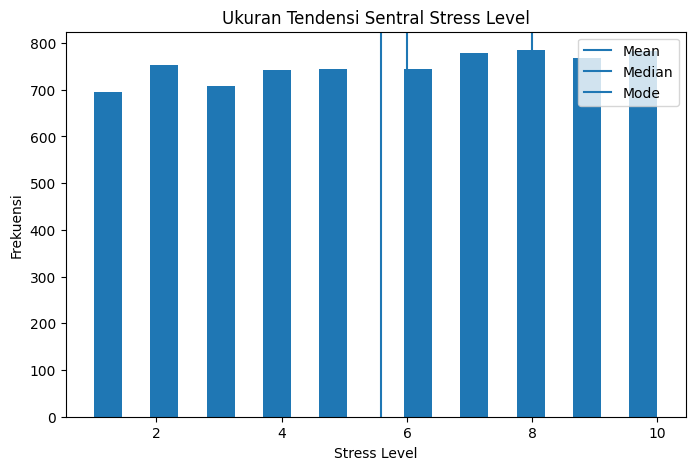

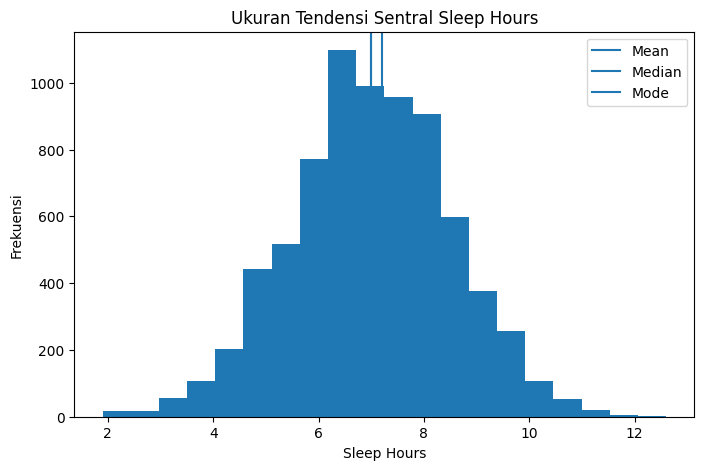

In [81]:
bmi_mean = df['BMI'].mean()
bmi_median = df['BMI'].median()
bmi_mode = df['BMI'].mode()[0]

stress_mean = df['Stress_Level'].mean()
stress_median = df['Stress_Level'].median()
stress_mode = df['Stress_Level'].mode()[0]

sleep_mean = df['Sleep_Hours'].mean()
sleep_median = df['Sleep_Hours'].median()
sleep_mode = df['Sleep_Hours'].mode()[0]



plt.figure(figsize=(8,5))
plt.hist(df['BMI'], bins=20)
plt.axvline(bmi_mean, label='Mean')
plt.axvline(bmi_median, label='Median')
plt.axvline(bmi_mode, label='Mode')
plt.title('Ukuran Tendensi Sentral BMI')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()



plt.figure(figsize=(8,5))
plt.hist(df['Stress_Level'], bins=20)
plt.axvline(stress_mean, label='Mean')
plt.axvline(stress_median, label='Median')
plt.axvline(stress_mode, label='Mode')
plt.title('Ukuran Tendensi Sentral Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()



plt.figure(figsize=(8,5))
plt.hist(df['Sleep_Hours'], bins=20)
plt.axvline(sleep_mean, label='Mean')
plt.axvline(sleep_median, label='Median')
plt.axvline(sleep_mode, label='Mode')
plt.title('Ukuran Tendensi Sentral Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

In [ ]:
KESIMPULAN BERDASARKAN UKURAN TENDENSI SENTRAL

Pada dataset  ini, nilai mean dan median dari BMI, stress level, dan sleep hours cenderung berdekatan, sehingga menunjukkan
bahwa data cukup stabil dan tidak memiliki penyimpangan ekstrem yang terlalu besar.
    

In [64]:
print("BENTUK SKEWNESS DAN KURTOSIS \n")
print("\nBMI")
print("Skewness BMI :", df['BMI'].skew())
print("Kurtosis BMI :", df['BMI'].kurt())


print("\nStress Level")
print("Skewness Stress Level :", df['Stress_Level'].skew())
print("Kurtosis Stress Level :", df['Stress_Level'].kurt())

print("\nSleep Hours")
print("Skewness Sleep Hours :", df['Sleep_Hours'].skew())
print("Kurtosis Sleep Hours :", df['Sleep_Hours'].kurt())

BENTUK SKEWNESS DAN KURTOSIS 


BMI
Skewness BMI : 0.4146039271611543
Kurtosis BMI : 0.40436717843388026

Stress Level
Skewness Stress Level : -0.04057758645954167
Kurtosis Stress Level : -1.2216772955651953

Sleep Hours
Skewness Sleep Hours : -0.05155759914355601
Kurtosis Sleep Hours : 0.016506651529121452


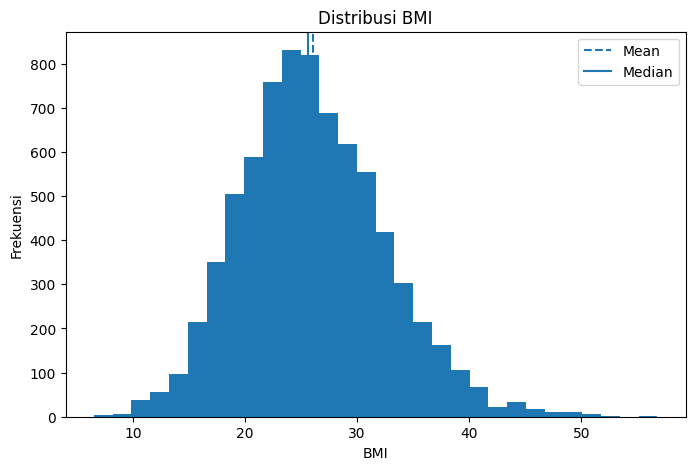

In [65]:
plt.figure(figsize=(8,5))

plt.hist(df['BMI'], bins=30)
plt.axvline(df['BMI'].mean(), linestyle='dashed', label='Mean')
plt.axvline(df['BMI'].median(), linestyle='solid', label='Median')
plt.title('Distribusi BMI')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

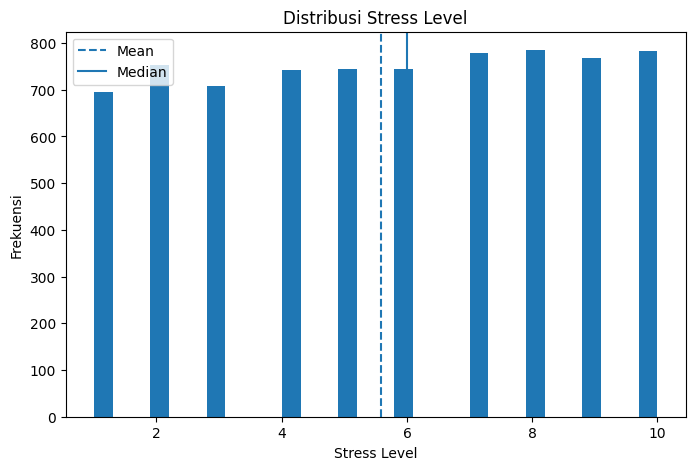

In [66]:
plt.figure(figsize=(8,5))

plt.hist(df['Stress_Level'], bins=30)

plt.axvline(df['Stress_Level'].mean(), linestyle='dashed', label='Mean')
plt.axvline(df['Stress_Level'].median(), linestyle='solid', label='Median')

plt.title('Distribusi Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')

plt.legend()

plt.show()

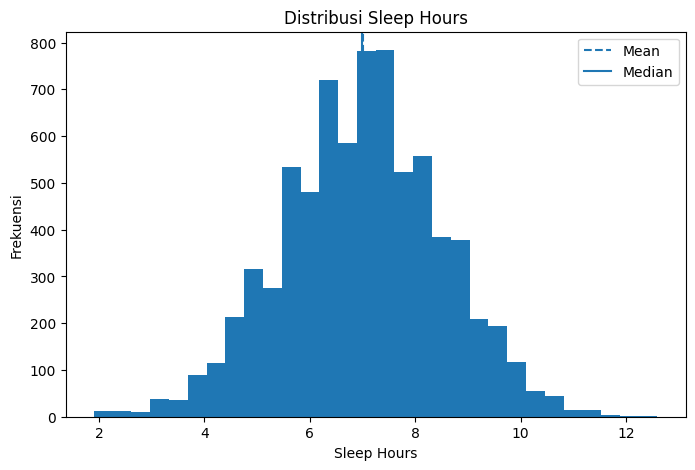

In [67]:
plt.figure(figsize=(8,5))

plt.hist(df['Sleep_Hours'], bins=30)

plt.axvline(df['Sleep_Hours'].mean(), linestyle='dashed', label='Mean')
plt.axvline(df['Sleep_Hours'].median(), linestyle='solid', label='Median')

plt.title('Distribusi Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frekuensi')

plt.legend()

plt.show()

In [ ]:
Secara keseluruhan, berdasarkan tabel perhitungan dan grafik distribusi dapat disimpulkan bahwa ketiga variabel utama dalam dataset ini memiliki
pola distribusi yang relatif normal, stabil, dan tidak terlalu banyak outlier ekstrem
Kedekatan antara nilai mean dan median pada setiap variabel juga mempertegas bahwa data memiliki penyebaran yang cukup baik sehingga layak 
digunakan untuk analisis statistik lanjutan

In [69]:
print(" VARIABILITAS DATA ")
print("\nBMI")
print("Range BMI :", df['BMI'].max() - df['BMI'].min())
print("Variansi BMI :", df['BMI'].var())
print("Standar Deviasi BMI :", df['BMI'].std())


print("\nStress Level")
print("Range Stress Level :", df['Stress_Level'].max() - df['Stress_Level'].min())
print("Variansi Stress Level :", df['Stress_Level'].var())
print("Standar Deviasi Stress Level :", df['Stress_Level'].std())



print("\nSleep Hours")
print("Range Sleep Hours :", df['Sleep_Hours'].max() - df['Sleep_Hours'].min())
print("Variansi Sleep Hours :", df['Sleep_Hours'].var())
print("Standar Deviasi Sleep Hours :", df['Sleep_Hours'].std())

 VARIABILITAS DATA 

BMI
Range BMI : 50.3
Variansi BMI : 41.37591563870738
Standar Deviasi BMI : 6.432411339358467

Stress Level
Range Stress Level : 9
Variansi Stress Level : 8.213855696315063
Standar Deviasi Stress Level : 2.865982501048299

Sleep Hours
Range Sleep Hours : 10.7
Variansi Sleep Hours : 2.2922383606703116
Standar Deviasi Sleep Hours : 1.5140139895887064


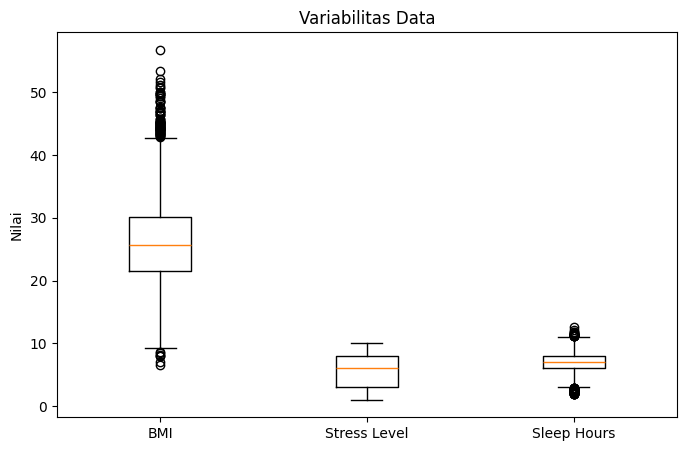

In [70]:
plt.figure(figsize=(8,5))
plt.boxplot([
    df['BMI'],
    df['Stress_Level'],
    df['Sleep_Hours']
])

plt.xticks([1,2,3], ['BMI', 'Stress Level', 'Sleep Hours'])
plt.title('Variabilitas Data')
plt.ylabel('Nilai')
plt.show()

In [ ]:
KESIMPULAN BERDASARKAN VARIABILITAS DATA

Berdasarkan hasil perhitungan variabilitas dan visualisasi boxplot,
dapat dilihat bahwa setiap variabel memiliki tingkat penyebaran data yang berbeda.

Variabel dengan standar deviasi dan variansi yang lebih besar menunjukkan bahwa data lebih bervariasi dan memiliki penyebaran
yang lebih luas dari rata-ratanya Sedangkan variabel dengan standar deviasi yang kecil menunjukkan bahwa sebagian besar data
berkumpul di sekitar nilai rata-rata sehingga data lebih stabil dan konsisten

Pada boxplot, penyebaran data dapat dilihat dari panjang kotak dan whisker Semakin panjang bentuk boxplot, maka semakin tinggi 
variabilitas datanya Selain itu, jika terdapat titik yang jauh dari boxplot utama, maka data tersebut termasuk outlier atau nilai ekstrem

Secara keseluruhan, data BMI, Stress Level, dan Sleep Hours pada dataset ini masih menunjukkan penyebaran yang cukup normal dan stabil
karena sebagian besar data tetap berada di sekitar nilai tengah tanpa adanya penyimpangan ekstrem yang terlalu dominan.

In [71]:
print(" Uji Korelasi BMI dan Stress Level\n")
korelasi = df['BMI'].corr(df['Stress_Level'])
print(korelasi)

 Uji Korelasi BMI dan Stress Level

-0.011619467116235245


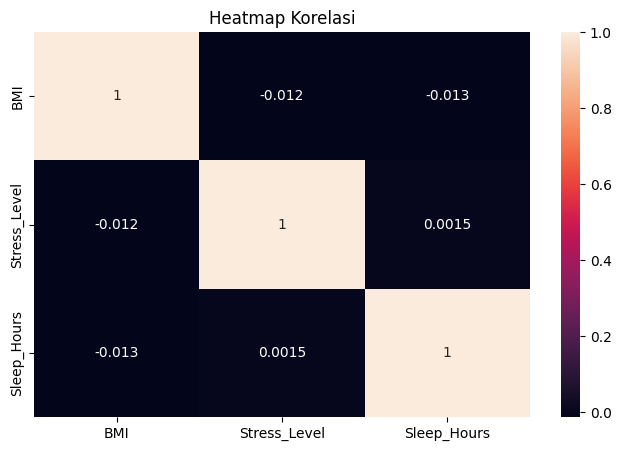

In [79]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['BMI', 'Stress_Level', 'Sleep_Hours']].corr(),
    annot=True
)

plt.title('Heatmap Korelasi')

plt.show()

In [ ]:
Karena nilai dari uji korelasinya  sangat dekat dengan 0, maka dapat disimpulkan bahwa perubahan pada satu variabel hampir tidak
memengaruhi variabel lainnya.

In [76]:
# konsep T-Test
print("Membandingkan BMI smoker vs non-smoker:")

from scipy.stats import ttest_ind

smoker = df[df['Smoker'] == 'Yes']['BMI']
nonsmoker = df[df['Smoker'] == 'No']['BMI']
t_stat, p_value = ttest_ind(smoker, nonsmoker)
print("Smoker :", t_stat)
print("non-Smoker :", p_value)

Membandingkan BMI smoker vs non-smoker:
Smoker : 0.378281659111275
non-Smoker : 0.7052320779018083


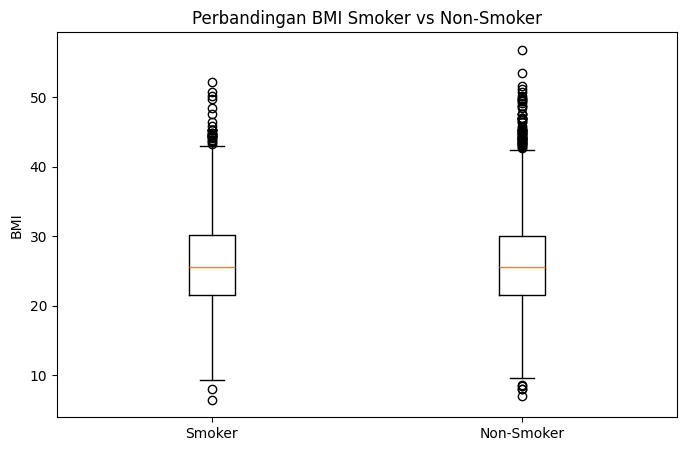

In [80]:
#visualisasi Perbandingan

smoker = df[df['Smoker'] == 'Yes']['BMI']
nonsmoker = df[df['Smoker'] == 'No']['BMI']
plt.figure(figsize=(8,5))
plt.boxplot([smoker, nonsmoker],
           tick_labels=['Smoker', 'Non-Smoker'])
plt.title('Perbandingan BMI Smoker vs Non-Smoker')
plt.ylabel('BMI')
plt.show()

In [ ]:
berdasarkan hasil perbandingan ini  dapat disimpulkan  dataset menjelaskan bahwa :

1)kebiasaan merokok belum menunjukkan pengaruh yang signifikan,
2)perbedaan rata-rata antara smoker dan non-smoker masih tergolong kecil,
3) variasi data antar kelompok masih dianggap normal secara statistik.

Hal ini juga sejalan dengan hasil statistik deskriptif sebelumnya, di mana rata-rata BMI maupun stress level antara smoker dan non-smoker
memang terlihat hampir sama.

In [ ]:
KESIMPULAN 

Berdasarkan hasil analisis statistik deskriptif dan inferensial pada dataset health lifestyle, diperoleh bahwa distribusi data BMI, Stress Level, 
dan Sleep Hours cenderung normal dan stabil karena nilai mean, median, serta modus relatif berdekatan dan tidak terdapat penyimpangan ekstrem 
yang signifikan

Hasil pengelompokan data menunjukkan bahwa gender, kebiasaan merokok, dan frekuensi olahraga tidak memberikan perbedaan yang terlalu besar 
terhadap BMI maupun tingkat stres Hal ini diperkuat oleh uji korelasi yang menghasilkan nilai sangat lemah (-0.0116) sehingga hubungan antar
variabel hampir tidak ada, serta uji t-test dengan p-value > 0.05 yang menunjukkan tidak adanya perbedaan signifikan antara smoker dan non-smoker.

Visualisasi histogram, scatter plot, heatmap, dan boxplot juga mendukung hasil analisis bahwa pola data relatif stabil, menyebar normal,
dan tidak menunjukkan hubungan yang kuat antar variabel Secara keseluruhan, dataset ini menunjukkan bahwa faktor gaya hidup pada data yang
dianalisis belum memiliki pengaruh signifikan terhadap kondisi kesehatan responden.